# VTI Academy - Phân tích thị trường kỹ năng và ứng dụng cho HR

Bài nộp dạng notebook. Mỗi mục được trình bày theo cùng một mạch: số liệu, một biểu đồ minh họa phù hợp, rồi tới phần **Nhận xét** (phát hiện) và **Hành động HR** (việc cần làm).

Phần phân tích dùng lại các hàm trong `vti_hr_curriculum_market_insight.py` để số liệu trên notebook và khi chạy bằng dòng lệnh luôn khớp nhau.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from vti_hr_curriculum_market_insight import (
    load_data, prepare_data, dataset_overview, data_dictionary_table,
    dataset_profile, build_clean_dataset, market_signal, role_ide_matrix,
    salary_by_language, salary_growth_cross_insight, role_summary_for_hr,
    role_skill_summary, hr_role_priority, hr_action_plan, jd_keyword_map,
    interview_rubric, training_roadmap, make_executive_summary,
    MIN_SALARY_SAMPLE, SALARY_CAP,
)

plt.rcParams.update({
    'figure.figsize': (9, 5),
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

C = {
    'primary': '#2563eb', 'good': '#16a34a', 'bad': '#dc2626',
    'muted': '#94a3b8', 'accent': '#9333ea',
}

In [2]:
# Bộ hàm vẽ, mỗi hàm là một loại biểu đồ chuyên nghiệp khác nhau.
def chart_bar(df, label_col, value_col, title, color=None, fmt='{:,.0f}'):
    d = df.sort_values(value_col)
    fig, ax = plt.subplots()
    bars = ax.barh(d[label_col].astype(str), d[value_col], color=color or C['primary'])
    for b, v in zip(bars, d[value_col]):
        ax.text(v, b.get_y() + b.get_height()/2, ' ' + fmt.format(v), va='center', fontsize=9)
    ax.set_title(title); ax.set_xlabel(value_col)
    plt.tight_layout(); plt.show()

def chart_donut(df, label_col, value_col, title):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.pie(df[value_col], labels=df[label_col], autopct='%1.0f%%', pctdistance=0.8,
           startangle=90, wedgeprops=dict(width=0.42, edgecolor='white'))
    ax.set_title(title)
    plt.tight_layout(); plt.show()

def chart_diverging(df, label_col, value_col, title, top_n=12):
    d = df.reindex(df[value_col].abs().sort_values(ascending=False).index).head(top_n)
    d = d.sort_values(value_col)
    colors = [C['good'] if v >= 0 else C['bad'] for v in d[value_col]]
    fig, ax = plt.subplots()
    ax.barh(d[label_col].astype(str), d[value_col], color=colors)
    ax.axvline(0, color='#334155', lw=0.8)
    ax.set_title(title); ax.set_xlabel(value_col)
    plt.tight_layout(); plt.show()

def chart_grouped(df, label_col, cols, title, top_n=10):
    d = df.head(top_n).iloc[::-1]
    y = np.arange(len(d)); h = 0.38
    fig, ax = plt.subplots()
    ax.barh(y - h/2, d[cols[0]], height=h, label=cols[0], color=C['muted'])
    ax.barh(y + h/2, d[cols[1]], height=h, label=cols[1], color=C['primary'])
    ax.set_yticks(y); ax.set_yticklabels(d[label_col].astype(str))
    ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

def chart_lollipop(df, label_col, value_col, title, top_n=12):
    d = df.head(top_n).sort_values(value_col)
    fig, ax = plt.subplots()
    ax.hlines(d[label_col].astype(str), 0, d[value_col], color=C['muted'], lw=2)
    ax.plot(d[value_col], d[label_col].astype(str), 'o', color=C['accent'], ms=9)
    for v, l in zip(d[value_col], d[label_col].astype(str)):
        ax.text(v, l, f' {v:,.0f}', va='center', fontsize=9)
    ax.set_title(title); ax.set_xlabel(value_col)
    plt.tight_layout(); plt.show()

def chart_bubble(df, x, y, size, label_col, title, highlight=None):
    d = df.dropna(subset=[x, y]).copy()
    d = d[d[size] >= 500]
    fig, ax = plt.subplots()
    sc = ax.scatter(d[x], d[y], s=(d[size]/15).clip(30, 600), c=d[x],
                    cmap='viridis', alpha=0.75, edgecolor='white', linewidth=0.5)
    for _, r in d.iterrows():
        if highlight is None or r[label_col] in highlight:
            ax.annotate(r[label_col], (r[x], r[y]), fontsize=8,
                        xytext=(4, 4), textcoords='offset points')
    ax.axhline(d[y].median(), color=C['muted'], ls='--', lw=0.8)
    ax.axvline(0, color=C['muted'], ls='--', lw=0.8)
    ax.set_xlabel('Tăng trưởng (%)'); ax.set_ylabel('Lương trung vị (USD)')
    ax.set_title(title)
    plt.colorbar(sc, label='Tăng trưởng (%)')
    plt.tight_layout(); plt.show()

def chart_heatmap(pivot, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=40, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    mx = pivot.values.max()
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if v > 0:
                ax.text(j, i, int(v), ha='center', va='center', fontsize=8,
                        color='white' if v > mx*0.55 else '#1e293b')
    ax.set_title(title)
    plt.colorbar(im, label='Số developer')
    plt.tight_layout(); plt.show()

def chart_priority(df, title):
    band = {'Priority 1': C['good'], 'Priority 2': C['primary'], 'Priority 3': C['muted']}
    d = df.sort_values('hiring_priority_score')
    colors = [band.get(b, C['muted']) for b in d['priority_band']]
    fig, ax = plt.subplots()
    bars = ax.barh(d['role'], d['hiring_priority_score'], color=colors)
    for b, v in zip(bars, d['hiring_priority_score']):
        ax.text(v, b.get_y() + b.get_height()/2, f' {v:.0f}', va='center', fontsize=9)
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in band.values()]
    ax.legend(handles, band.keys(), title='Nhóm ưu tiên', fontsize=9)
    ax.set_title(title); ax.set_xlabel('Điểm ưu tiên (0-100)')
    plt.tight_layout(); plt.show()

## Đọc và chuẩn bị dữ liệu

In [3]:
from pathlib import Path
candidates = [
    Path('Final Project.csv'), Path('Final Project (1).csv'),
    Path(r'C:/Users/User/Downloads/Final Project.csv'),
]
DATA_PATH = next((p for p in candidates if p.exists()), candidates[0])
raw = load_data(DATA_PATH)
df = prepare_data(raw)
print(f'Đã đọc {len(df):,} dòng, {df.shape[1]} cột từ {DATA_PATH}')

Đã đọc 11,552 dòng, 90 cột từ C:\Users\User\Downloads\Final Project.csv


## Mục 0. Tổng quan dữ liệu
**Nhận xét:** dữ liệu đủ lớn để đọc tín hiệu thị trường toàn cầu, nhưng phần của Việt Nam còn nhỏ. Mẫu thiên về developer chuyên nghiệp tầm trung và phần lớn làm toàn thời gian.

**Hành động HR:** coi đây là tín hiệu toàn cầu để định hướng curriculum, sau đó kiểm chứng riêng nhu cầu nội địa bằng tin tuyển dụng và dữ liệu ứng viên.

*Biểu đồ: donut cơ cấu tình trạng việc làm.*

,metric,value,hr_meaning
0,Total respondents,11552.0,Large enough for global talent signal and curr...
1,Countries covered,135.0,"Useful for global benchmark, not only one loca..."
2,Viet Nam responses,12.0,Vietnam sample is small; HR should validate lo...
3,Median salary USD,57844.0,Use median as reference point for compensation...
4,Median professional coding years,5.0,The survey reflects mid-level professional dev...
5,Employed full-time percentage,96.2,Signals are relevant for professional hiring a...
6,Average languages worked per respondent,5.2,Modern developers are polyglot; JD and trainin...
7,Average languages desired per respondent,4.9,Candidates want multi-skill growth; learning b...


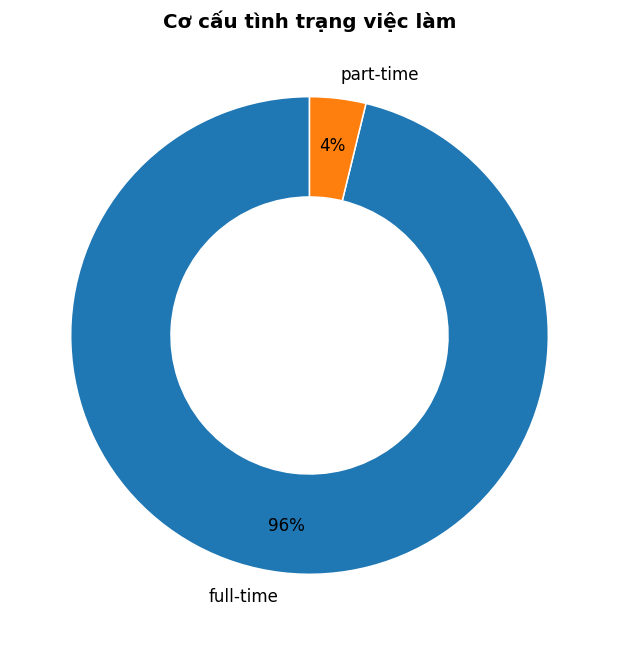

In [4]:
overview = dataset_overview(df)
display(overview)

emp = df['Employment'].value_counts().head(4).reset_index()
emp.columns = ['employment', 'count']
emp['employment'] = emp['employment'].str.replace('Employed ', '').str.replace('Independent contractor, freelancer, or self-employed', 'Freelancer/Self-employed')
chart_donut(emp, 'employment', 'count', 'Cơ cấu tình trạng việc làm')

## Mục C.1. Từ điển dữ liệu
**Nhận xét:** mỗi cột dùng trong bài được ánh xạ rõ về câu hỏi khảo sát gốc và lý do sử dụng, nên người chấm truy ngược được mọi con số về đúng cột nguồn.

**Hành động HR:** xem bảng này như một cam kết về dữ liệu, mọi nhận xét phía sau đều bắt nguồn từ các cột đã liệt kê.

*Đây là bảng tra cứu nên trình bày dạng bảng, không cần biểu đồ.*

In [5]:
display(data_dictionary_table())

,column_name,survey_question_vi,role_in_analysis
0,Respondent,Mã ID người trả lời được ngẫu nhiên hóa.,"Khóa định danh duy nhất, dùng để đếm số develo..."
1,Country,Bạn hiện đang cư trú ở quốc gia nào?,"Tách tín hiệu toàn cầu với Việt Nam, và nhắc r..."
2,Employment,Tình trạng việc làm hiện tại của bạn?,Đo tỷ lệ làm toàn thời gian để khẳng định đây ...
3,DevType,Những điều nào sau đây mô tả về bạn? (chọn nhi...,Nhận diện vai trò để xếp thứ tự ưu tiên tuyển ...
4,YearsCodePro,Bạn đã viết mã chuyên nghiệp được bao nhiêu năm?,Quy đổi về số năm để đo mức kinh nghiệm trung ...
5,ConvertedComp,Tổng thu nhập quy đổi sang USD mỗi năm.,Tín hiệu lương; cắt ngọn rồi lấy trung vị theo...
6,LanguageWorkedWith,Ngôn ngữ đã làm việc trong năm qua (chọn nhiều).,Là vế 'đang dùng' của tín hiệu ngôn ngữ và để ...
7,LanguageDesireNextYear,Ngôn ngữ muốn làm việc năm tới (chọn nhiều).,"Là vế 'muốn dùng', dùng để tính mức tăng trưởn..."
8,DatabaseWorkedWith,Cơ sở dữ liệu đã làm việc trong năm qua (chọn ...,Là vế 'đang dùng' của tín hiệu cơ sở dữ liệu.
9,DatabaseDesireNextYear,Cơ sở dữ liệu muốn làm việc năm tới (chọn nhiều).,"Là vế 'muốn dùng', giúp chọn cơ sở dữ liệu làm..."


## Mục C.2. Chất lượng dữ liệu
**Nhận xét:** cột lương hay bị thiếu nhất vì nhiều người bỏ trống thu nhập; các cột nhiều lựa chọn cũng có một phần ô trống.

**Hành động HR:** với phần lương chỉ dùng trung vị kèm cỡ mẫu, và bỏ qua dòng thiếu khi tính tín hiệu thay vì điền bừa.

*Biểu đồ: thanh ngang tỷ lệ ô trống theo cột.*

,column_name,missing_count,missing_pct
0,DatabaseDesireNextYear,1055,9.1
1,ConvertedComp,822,7.1
2,DatabaseWorkedWith,456,3.9
3,LanguageDesireNextYear,137,1.2
4,DevType,67,0.6
5,DevEnviron,29,0.3
6,LanguageWorkedWith,11,0.1
7,YearsCodePro,16,0.1
8,Employment,0,0.0
9,Respondent,0,0.0


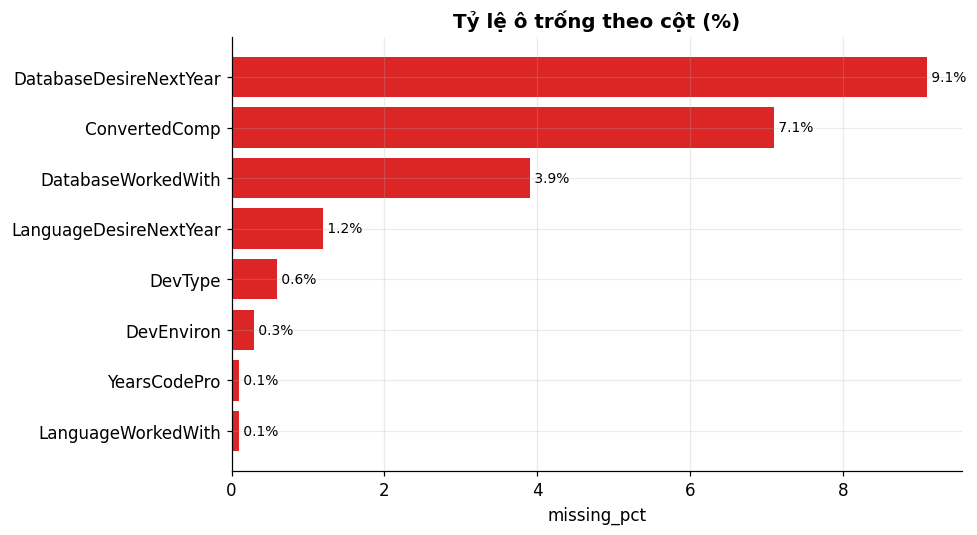

In [6]:
profile = dataset_profile(df)
miss = profile['missing'][profile['missing']['missing_pct'] > 0]
display(profile['missing'])
chart_bar(miss, 'column_name', 'missing_pct', 'Tỷ lệ ô trống theo cột (%)',
          color=C['bad'], fmt='{:.1f}%')

## Mục C.2b. Phân bố theo quốc gia
**Nhận xét:** mẫu nghiêng về một số nước phát triển, còn Việt Nam chỉ chiếm phần rất nhỏ.

**Hành động HR:** đọc như một mốc tham chiếu toàn cầu và kiểm chứng riêng cho thị trường Việt Nam.

*Biểu đồ: thanh ngang top quốc gia.*

,Country,count,pct
0,United States,3173,27.5
1,India,911,7.9
2,United Kingdom,841,7.3
3,Germany,715,6.2
4,Canada,442,3.8
5,France,339,2.9
6,Brazil,328,2.8
7,Australia,287,2.5


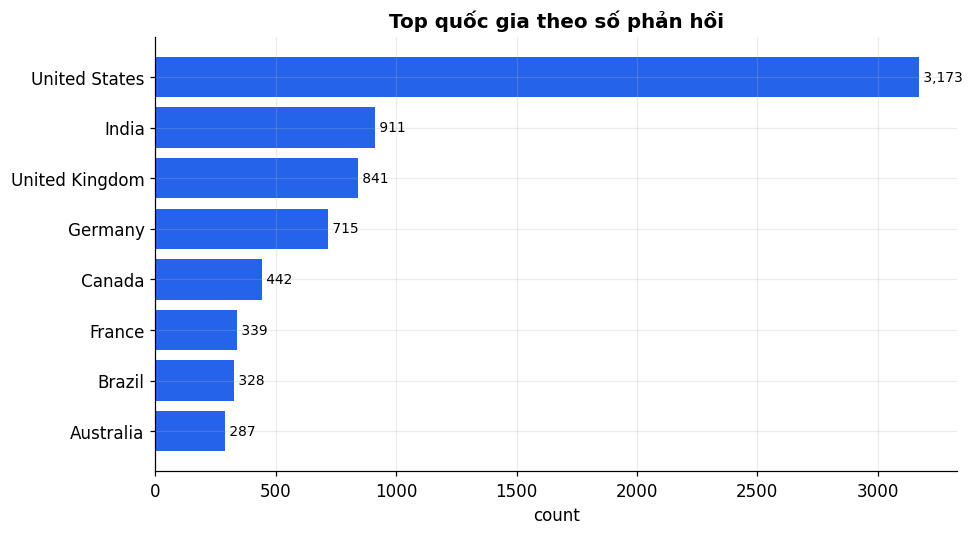

In [7]:
ctry = profile['country']
display(ctry)
chart_bar(ctry, 'Country', 'count', 'Top quốc gia theo số phản hồi')

## Mục C.3. Bộ dữ liệu sạch
**Nhận xét:** toàn bộ tên cột đã đưa về snake_case, bỏ khoảng trắng và ký tự đặc biệt.

**Hành động HR:** dùng `C_clean_dataset.csv` cho phân tích hoặc Power BI, đáp ứng yêu cầu sản phẩm nộp D.1.

In [8]:
clean_df = build_clean_dataset(df)
print('Số cột:', clean_df.shape[1])
print('Ví dụ tên cột:', ', '.join(list(clean_df.columns)[:12]), '...')
clean_df.to_csv('C_clean_dataset.csv', index=False, encoding='utf-8-sig')
display(clean_df.head())

Số cột: 90
Ví dụ tên cột: respondent, main_branch, hobbyist, open_sourcer, open_source, employment, country, student, ed_level, undergrad_major, edu_other, org_size ...


,respondent,main_branch,hobbyist,open_sourcer,open_source,employment,country,student,ed_level,undergrad_major,...,sexuality,ethnicity,dependents,survey_length,survey_ease,years_code_pro_num,salary_usd,salary_winsorized,language_count_worked,language_count_desired
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy,0.5,61000.0,61000.0,5,4
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult,4.0,95179.0,95179.0,11,10
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy,8.0,90000.0,90000.0,6,7
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult,3.0,455352.0,300000.0,6,6
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy,2.0,65277.0,65277.0,4,6


## Mục 1. Tín hiệu ngôn ngữ lập trình
**Nhận xét:** số người đang dùng và số người muốn dùng năm sau là hai chuyện khác nhau. Phổ biến không có nghĩa là đang tăng trưởng.

**Hành động HR:** tách rõ kỹ năng nền tảng với kỹ năng tăng trưởng khi thiết kế curriculum và JD.

*Biểu đồ: thanh phân kỳ mức thay đổi ròng (xanh là mở rộng, đỏ là co lại).*

,language,worked,desired_next_year,net_change,growth_pct,desired_market_pct,signal
0,JavaScript,8805,6715,-2090,-23.7,58.1,Declining
1,HTML/CSS,7920,5398,-2522,-31.8,46.7,Declining
2,Python,4611,5309,698,15.1,46.0,Stable
3,SQL,7213,5094,-2119,-29.4,44.1,Declining
4,TypeScript,3269,4140,871,26.6,35.8,Emerging
5,C#,4346,3639,-707,-16.3,31.5,Stable
6,Bash/Shell/PowerShell,4694,3135,-1559,-33.2,27.1,Declining
7,Java,4556,2987,-1569,-34.4,25.9,Declining
8,Go,1133,2813,1680,148.3,24.4,Emerging
9,Kotlin,754,1907,1153,152.9,16.5,Emerging


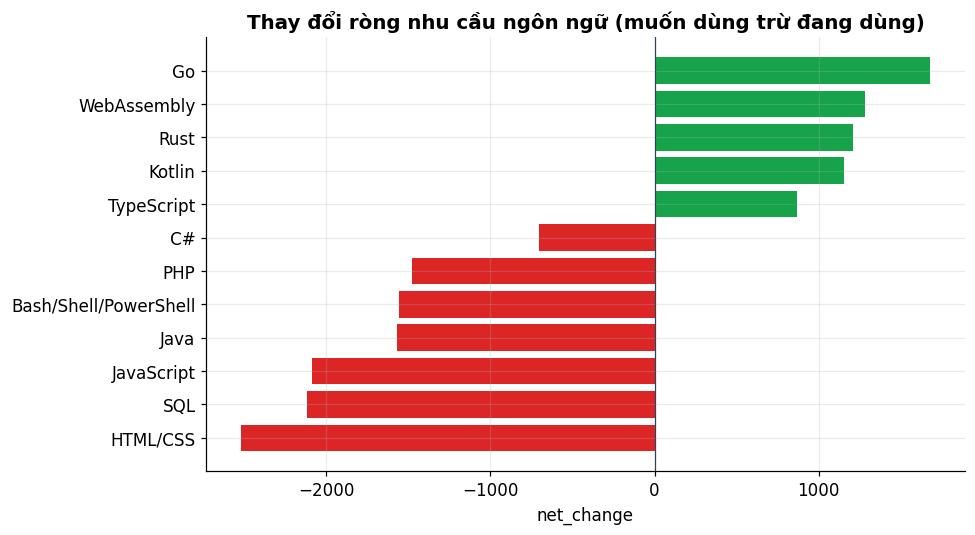

In [9]:
language_signal = market_signal(df, 'LanguageWorkedWith', 'LanguageDesireNextYear', 'language')
display(language_signal.head(12))
chart_diverging(language_signal, 'language', 'net_change',
                'Thay đổi ròng nhu cầu ngôn ngữ (muốn dùng trừ đang dùng)')

## Mục 2. Tín hiệu cơ sở dữ liệu
**Nhận xét:** PostgreSQL vừa có nhu cầu lớn vừa tăng trưởng ổn định; Redis, MongoDB, Elasticsearch là các lớp bổ trợ.

**Hành động HR:** chọn PostgreSQL làm cơ sở dữ liệu trục chính, đưa các lựa chọn còn lại vào phần nâng cao theo track.

*Biểu đồ: thanh nhóm so sánh đang dùng và muốn dùng.*

,database,worked,desired_next_year,net_change,growth_pct,desired_market_pct,signal
0,PostgreSQL,4153,4386,233,5.6,38.0,Stable
1,MongoDB,3058,3703,645,21.1,32.1,Emerging
2,Redis,2536,3385,849,33.5,29.3,Emerging
3,MySQL,5549,3328,-2221,-40.0,28.8,Declining
4,Elasticsearch,1980,2898,918,46.4,25.1,Emerging
5,Microsoft SQL Server,4170,2747,-1423,-34.1,23.8,Declining
6,SQLite,3292,2465,-827,-25.1,21.3,Declining
7,Firebase,1343,1679,336,25.0,14.5,Emerging
8,MariaDB,1724,1400,-324,-18.8,12.1,Stable
9,DynamoDB,839,1056,217,25.9,9.1,Emerging


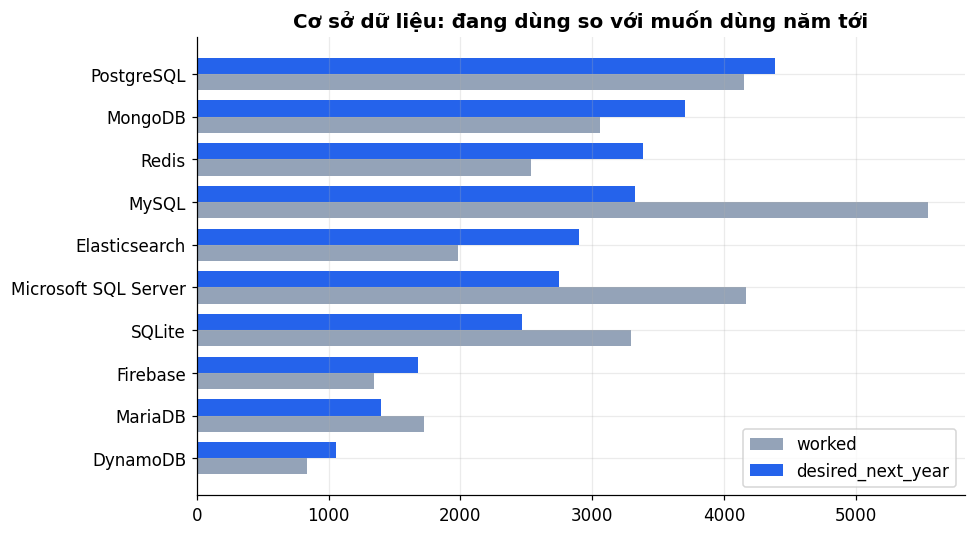

In [10]:
database_signal = market_signal(df, 'DatabaseWorkedWith', 'DatabaseDesireNextYear', 'database')
display(database_signal.head(12))
chart_grouped(database_signal, 'database', ['worked', 'desired_next_year'],
              'Cơ sở dữ liệu: đang dùng so với muốn dùng năm tới')

## Mục 3. IDE theo vai trò
**Nhận xét:** VS Code chiếm ưu thế ở gần như mọi vai trò, bên cạnh đó mỗi track có thêm công cụ riêng.

**Hành động HR:** lấy VS Code và Git làm nền chung khi onboarding, rồi bổ sung công cụ chuyên biệt theo track.

*Biểu đồ: heatmap số developer theo vai trò và IDE.*

,role,rank,ide,developer_count
19,Back-end Developer,1,Visual Studio Code,3575
18,Back-end Developer,2,Visual Studio,2311
10,Back-end Developer,3,Notepad++,2027
27,Data Scientist / ML,1,IPython / Jupyter,390
39,Data Scientist / ML,2,Visual Studio Code,373
32,Data Scientist / ML,3,PyCharm,273
60,Data/BI Analyst,1,Visual Studio Code,408
51,Data/BI Analyst,2,Notepad++,350
59,Data/BI Analyst,3,Visual Studio,346
82,DevOps Specialist,1,Visual Studio Code,996


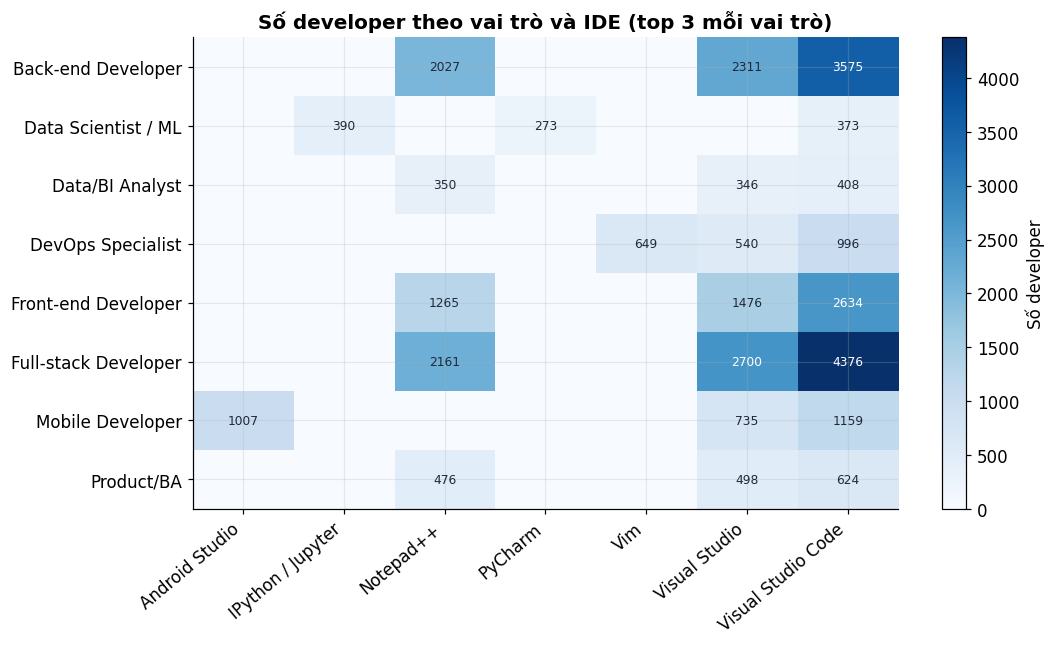

In [11]:
ide_role = role_ide_matrix(df)
top_ide_role = ide_role[ide_role['rank'] <= 3].copy()
display(top_ide_role.head(15))
pivot = (top_ide_role.pivot_table(index='role', columns='ide',
         values='developer_count', aggfunc='sum').fillna(0))
chart_heatmap(pivot, 'Số developer theo vai trò và IDE (top 3 mỗi vai trò)')

## Mục 4. Lương theo ngôn ngữ
**Nhận xét:** lương là số liệu tự khai và có giá trị bất thường; trung vị đáng tin hơn trung bình và phải đọc kèm cỡ mẫu.

**Hành động HR:** xây dải lương dựa trên trung vị kèm cỡ mẫu, kiểm chứng lại bằng dữ liệu lương Việt Nam trước khi áp dụng.

*Biểu đồ: lollipop lương trung vị theo ngôn ngữ.*

,language,developer_count,median_salary,mean_salary,mean_vs_global_pct
0,Clojure,152,93404.0,114203.0,44.1
1,Go,1060,80000.0,98923.0,24.8
2,Scala,461,79163.0,98884.0,24.7
3,Ruby,1094,75000.0,94376.0,19.0
4,Elixir,169,71966.0,89015.0,12.3
5,Rust,311,70000.0,88382.0,11.5
6,Bash/Shell/PowerShell,4417,68745.0,89946.0,13.5
7,Objective-C,483,64115.0,87429.0,10.3
8,Python,4293,64000.0,85750.0,8.2
9,R,552,63016.0,85477.0,7.8


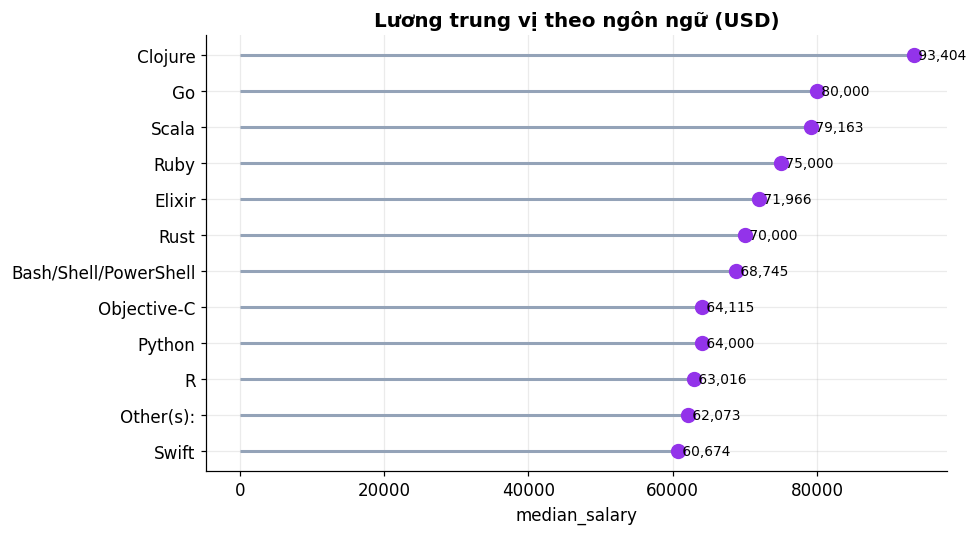

In [12]:
salary_language = salary_by_language(df)
display(salary_language.head(12))
chart_lollipop(salary_language, 'language', 'median_salary',
               'Lương trung vị theo ngôn ngữ (USD)')

## Mục 5. Giao thoa giữa lương, tăng trưởng và nhu cầu
**Nhận xét:** lựa chọn tốt nhất nằm ở chỗ giao nhau của ba tín hiệu: tăng trưởng cao, lương tốt và đủ lượng nhu cầu.

**Hành động HR:** ưu tiên nhóm vừa tăng trưởng vừa lương tốt; giữ nhóm nền tảng ổn định; chỉ theo dõi nhóm hẹp hoặc đang đi xuống.

*Biểu đồ: bubble, trục ngang là tăng trưởng, trục dọc là lương, kích thước là nhu cầu.*

,language,desired_next_year,worked,net_change,growth_pct,signal,salary_sample_size,median_salary,mean_salary,recommendation
0,JavaScript,6715,8805,-2090,-23.7,Declining,8136.0,58000.0,79063.0,"Keep as foundation, but avoid over-expansion"
1,HTML/CSS,5398,7920,-2522,-31.8,Declining,7325.0,57180.0,77753.0,"Keep as foundation, but avoid over-expansion"
3,SQL,5094,7213,-2119,-29.4,Declining,6687.0,58284.0,78852.0,"Keep as foundation, but avoid over-expansion"
6,Bash/Shell/PowerShell,3135,4694,-1559,-33.2,Declining,4417.0,68745.0,89946.0,"Keep as foundation, but avoid over-expansion"
4,TypeScript,4140,3269,871,26.6,Emerging,3012.0,60173.0,80456.0,Mass-market growth skill
2,Python,5309,4611,698,15.1,Stable,4293.0,64000.0,85750.0,Monitor
5,C#,3639,4346,-707,-16.3,Stable,3993.0,59112.0,79957.0,Monitor
7,Java,2987,4556,-1569,-34.4,Declining,4168.0,53437.0,75838.0,Monitor
10,C++,1645,1964,-319,-16.2,Stable,1792.0,54480.0,77329.0,Monitor
12,PHP,1475,2950,-1475,-50.0,Declining,2720.0,43296.0,66879.0,Monitor


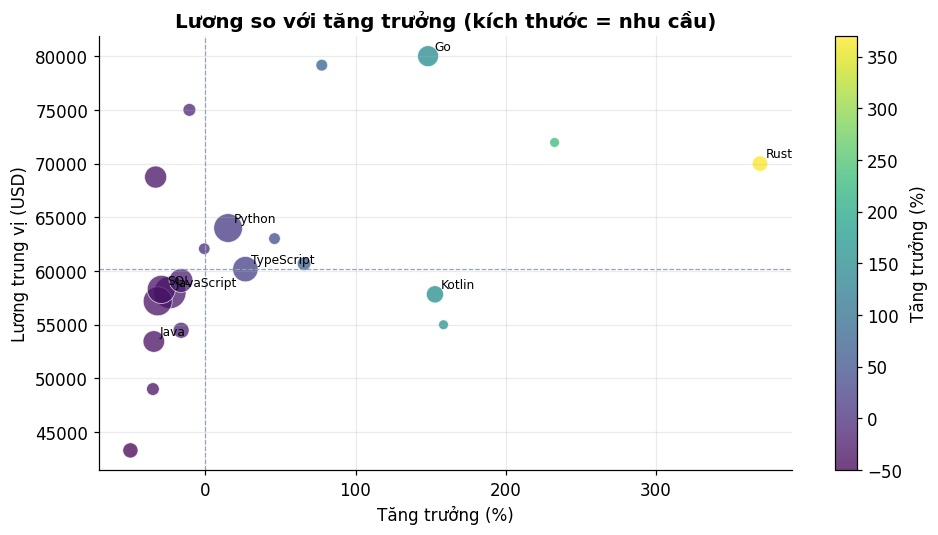

In [13]:
cross = salary_growth_cross_insight(language_signal, salary_language)
display(cross.head(12))
highlight = ['Go', 'Kotlin', 'TypeScript', 'Python', 'Rust', 'JavaScript', 'Java', 'SQL']
chart_bubble(cross, 'growth_pct', 'median_salary', 'desired_next_year', 'language',
             'Lương so với tăng trưởng (kích thước = nhu cầu)', highlight=highlight)

## Mục 6. Ưu tiên tuyển dụng theo vai trò
**Nhận xét:** có thể quy tín hiệu thị trường thành điểm ưu tiên và phân nhóm cho từng vai trò, thay vì chỉ liệt kê công nghệ phổ biến.

**Hành động HR:** xây pipeline lõi cho Priority 1, pipeline gọn cho Priority 2, và chỉ tuyển theo nhu cầu cụ thể cho Priority 3.

*Biểu đồ: thanh ngang tô màu theo nhóm ưu tiên.*

,role,developer_count,median_salary,hiring_priority_score,priority_band
0,Full-stack Developer,6928,59000.0,72.9,Priority 1
1,Back-end Developer,6290,56715.0,65.9,Priority 2
2,DevOps Specialist,1639,71036.0,46.1,Priority 2
3,Front-end Developer,3920,53437.0,45.2,Priority 2
4,Product/BA,1179,61650.0,33.3,Priority 3
5,Data/BI Analyst,802,61872.0,30.8,Priority 3
6,Data Scientist / ML,803,60000.0,28.9,Priority 3
7,Mobile Developer,1959,46152.0,23.5,Priority 3


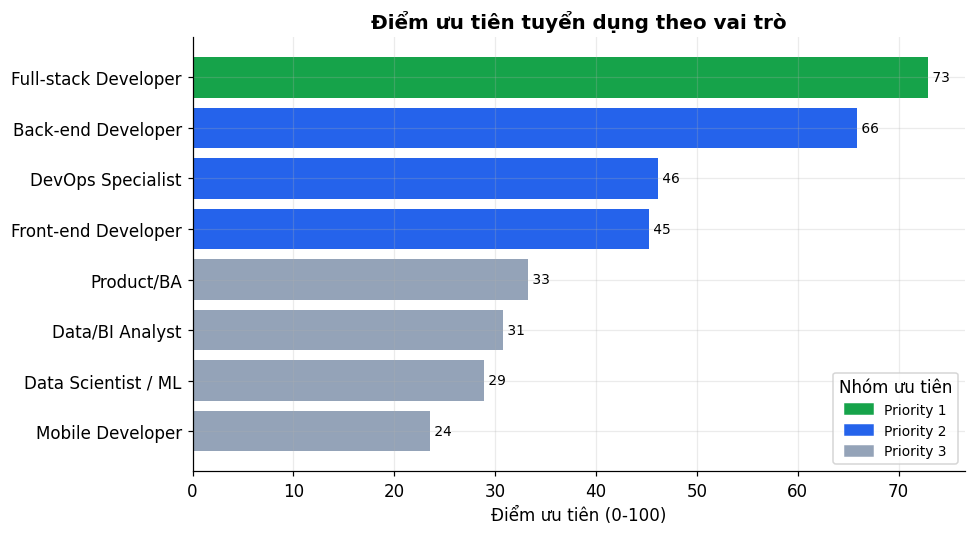

In [14]:
role_summary = role_summary_for_hr(df)
role_skills = role_skill_summary(df)
role_priority = hr_role_priority(role_summary, role_skills)
display(role_priority[['role', 'developer_count', 'median_salary', 'hiring_priority_score', 'priority_band']])
chart_priority(role_priority, 'Điểm ưu tiên tuyển dụng theo vai trò')

## Mục 7. Kế hoạch hành động HR
**Nhận xét:** mỗi mảng việc của HR đều có bằng chứng từ dữ liệu và một rủi ro đi kèm.

**Hành động HR:** dùng cột `immediate_action` để triển khai ngay và cột `risk` để biết chỗ cần thận trọng.

*Bảng kế hoạch, trình bày dạng bảng cho dễ đọc.*

In [15]:
hr_plan = hr_action_plan(overview, language_signal, database_signal, role_priority)
display(hr_plan)

,hr_area,what_hr_can_do,evidence_from_data,immediate_action,risk
0,Workforce planning,Translate skill demand into a yearly headcount...,"11,552 respondents; top desired languages: Jav...","Prioritize role tracks: Full-stack Developer, ...",Global survey may not fully represent Vietnam ...
1,Recruitment sourcing,"Use emerging skills as sourcing tags, not only...","Emerging language signals include: TypeScript,...","Create Boolean keyword strings for LinkedIn, T...",Overusing niche tags can shrink candidate pool...
2,Job description design,Separate must-have skills from nice-to-have gr...,"Top database signals include: PostgreSQL, Mong...","Write JDs with 3 layers: foundation, role-spec...",Too many keywords make JD unrealistic and redu...
3,Interview design,Turn skill signals into structured interview r...,The market is multi-stack; average developer u...,"Use a 100-point rubric: technical core, databa...",Unstructured interviews over-weight confidence...
4,Compensation benchmarking,Use median salary and sample size together bef...,Salary is self-reported and has outliers; medi...,"Create compensation bands by role, but validat...",Vietnam responses in this dataset are only 12;...
5,Learning and development,Use the same insight to reskill internal train...,VS Code dominates many roles; PostgreSQL/NoSQL...,Build a 4-week internal enablement path: VS Co...,Training without project assessment may look g...


## Mục 8. Bản đồ từ khóa cho JD
**Nhận xét:** mỗi track có nhóm từ khóa bắt buộc tách bạch với nhóm từ khóa tăng trưởng.

**Hành động HR:** viết JD theo ba lớp gồm nền tảng, stack theo vai trò và nhóm kỹ năng tăng trưởng; giữ danh sách bắt buộc ngắn gọn.

In [16]:
jd_map = jd_keyword_map(role_priority)
display(jd_map)

,role,hiring_track,must_have_keywords,growth_keywords,jd_rule
0,Full-stack Developer,Full-stack Engineering,"JavaScript, TypeScript, React, SQL, Git","Node.js, PostgreSQL, Docker, Cloud",Keep must-have list short. Use growth keywords...
1,Back-end Developer,Backend Engineering,"Java, Spring, SQL, PostgreSQL, API, Git","Go, TypeScript, Docker, Kubernetes, Redis",Keep must-have list short. Use growth keywords...
2,DevOps Specialist,Cloud and DevOps,"Linux, Docker, Kubernetes, AWS, CI/CD","Kubernetes, Terraform, Cloud, Monitoring",Keep must-have list short. Use growth keywords...
3,Front-end Developer,Frontend Engineering,"JavaScript, HTML/CSS, React, TypeScript, Git","TypeScript, Vue.js, Testing, API",Keep must-have list short. Use growth keywords...
4,Product/BA,Product and Business Analysis,"Requirement Analysis, SQL, Stakeholder, User S...","Data-driven Product, Experiment, Dashboard",Keep must-have list short. Use growth keywords...
5,Data/BI Analyst,Data Analytics,"SQL, Python, Excel, Power BI, Data Visualization","PostgreSQL, Python, Dashboard, Business Metrics",Keep must-have list short. Use growth keywords...
6,Data Scientist / ML,Data Science and ML,"Python, SQL, Statistics, Machine Learning, Jup...","PyTorch, TensorFlow, Cloud, MLOps",Keep must-have list short. Use growth keywords...
7,Mobile Developer,Mobile Engineering,"Kotlin, Android Studio, Swift, Xcode, API","Kotlin, Flutter, Mobile CI/CD",Keep must-have list short. Use growth keywords...


## Mục 9. Khung chấm phỏng vấn 100 điểm
**Nhận xét:** thị trường dùng nhiều stack nên buổi phỏng vấn cần chấm trên nhiều trục chứ không theo cảm tính.

**Hành động HR:** chuyển sang khung có trọng số tổng 100 điểm để chấm dựa trên bằng chứng kỹ năng.

*Biểu đồ: donut tỷ trọng các tiêu chí.*

,assessment_area,weight_pct,what_to_test,evidence_expected
0,Core technical skill,25,Main language or stack required by role.,"Can write, read, debug and explain code withou..."
1,Data and database thinking,20,"SQL, schema thinking, PostgreSQL/database conc...","Can explain trade-offs, not only memorize syntax."
2,Project evidence,20,"Past project, portfolio, business problem solv...","Clear problem, data/code approach, result and ..."
3,Tooling and workflow,15,"VS Code, Git, debugging, environment setup, ba...","Can work in a team workflow, not only in isola..."
4,Problem solving,10,"Small practical case, edge cases, reasoning un...","Explains assumptions, failure modes and next s..."
5,Communication,10,Ability to explain technical work to business/...,"Concise explanation, clear trade-off, no overc..."


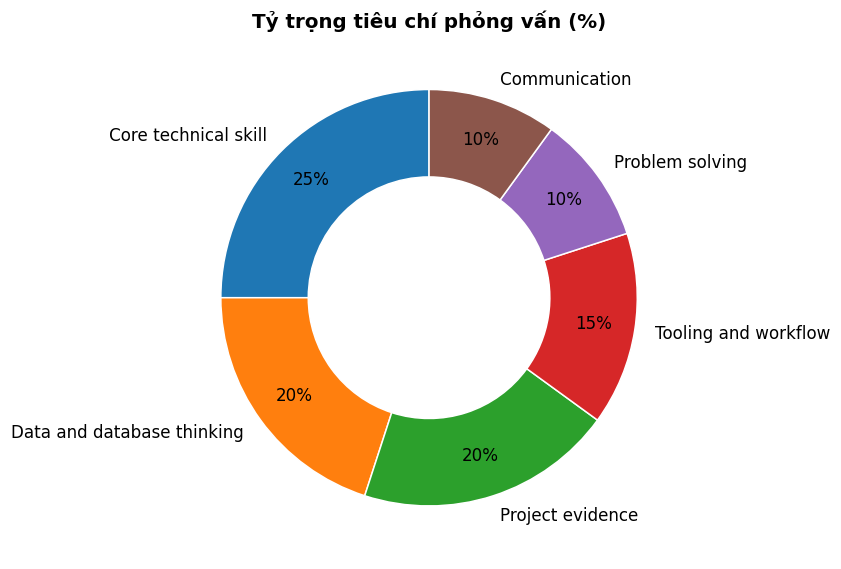

In [17]:
rubric = interview_rubric()
display(rubric)
chart_donut(rubric, 'assessment_area', 'weight_pct', 'Tỷ trọng tiêu chí phỏng vấn (%)')

## Mục 10. Lộ trình đào tạo 4 tuần
**Nhận xét:** lộ trình đi từ nền chung VS Code và Git, tới SQL và PostgreSQL, rồi stack theo vai trò và khép lại bằng review dự án.

**Hành động HR:** mỗi tuần đều có bằng chứng đầu ra rõ ràng để đo kết quả.

In [18]:
roadmap = training_roadmap()
display(roadmap)

,phase,training_block,target_roles,hr_reason,output_evidence
0,Week 1,"VS Code, Git and working environment",All technical roles,Creates common technical baseline and reduces ...,"Candidate can clone repo, run project, commit ..."
1,Week 2,SQL and PostgreSQL foundation,"Data, Backend, Full-stack",Database skill is a cross-role employability f...,"Candidate can query, join, aggregate and expla..."
2,Week 3,Role-specific stack,"Backend, Frontend, Mobile, Data, DevOps",Role-specific differentiation improves placeme...,Candidate completes a small practical role-bas...
3,Week 4,"Project, interview and communication review",All technical roles,"Employers hire evidence, not only skill names.","Candidate presents project, trade-offs, metric..."


## Mục 11. Tóm tắt và kết luận
Nguyên tắc cuối cùng: đừng tuyển người hay mở khóa học chỉ vì một công nghệ đang nóng. Hãy ưu tiên chỗ giao nhau của bốn tín hiệu là nhu cầu thị trường, tăng trưởng, mức lương và độ phù hợp vai trò.

In [19]:
summary = make_executive_summary(overview, language_signal, database_signal,
                                 role_priority, salary_language, hr_plan)
print(summary)

VTI Academy - HR and Curriculum Market Insight

Executive reading
The dataset contains 11,552 developers across 135 countries. Median salary is $57,844/year.
Vietnam has 12 responses, so this file is strong for global trend reading but weak for Vietnam-only salary or supply conclusions.

What HR can do with this insight
1. Workforce planning: prioritize role tracks where demand, salary and growth skills overlap.
2. Recruitment sourcing: use emerging skills as sourcing tags, but keep foundation skills in screening.
3. JD design: split skills into must-have, role-specific and nice-to-have growth keywords.
4. Interview design: move from unstructured interviews to a weighted rubric.
5. Compensation: use median and local validation, not global mean salary.
6. L&D: reskill trainers and junior candidates around VS Code/Git, SQL/PostgreSQL, role stack and project evidence.

Technology signal
Emerging language signals: WebAssembly (941.9), Rust (369.5), F# (298.1), Elixir (232.6), Erlang (217.3